In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parents[1]
sys.path.insert(0, str(project_root))

In [2]:
import coviar
import os
from pathlib import Path
import torch
from torch.utils.data import DataLoader
from modules.tokenization_clip import SimpleTokenizer as ClipTokenizer
from dataloaders.dataloader_msrvtt_retrieval import MSRVTT_DataLoader, MSRVTT_TrainDataLoader
from huggingface_hub import snapshot_download
import matplotlib.pyplot as plt
from compressed_domain.dataloader.download_data import download_via_hf

/tmp/clip4clip/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# download_via_hf()

Fetching 12 files: 100%|██████████| 12/12 [00:11<00:00,  1.03it/s]


In [3]:
train_path = "/storage/data/msrvtt/raw_data/MSRVTT_train.9k.csv"
val_path = "/storage/data/msrvtt/raw_data/MSRVTT_JSFUSION_test.csv"
json_path = "/storage/data/msrvtt/raw_data/MSRVTT_data.json"
features_path = "/storage/data/msrvtt/mpeg4_videos"

In [4]:
tokenizer = ClipTokenizer()
batch_size = 10
n_gpu = 1
num_thread_reader = 1
feature_framerate = 1

In [11]:
train_dataloader = MSRVTT_TrainDataLoader(
            train_path,
            json_path,
            features_path,
            tokenizer,
            feature_framerate=int(feature_framerate))

for step, batch in enumerate(train_dataloader):
    input_ids, input_mask, segment_ids, video, video_mask = batch
    break

print(video[0,1,0].shape)
print(input_ids.shape)
print(input_mask.shape)
print(video.shape)
print(video_mask.shape)
print(segment_ids.shape)
print(input_mask)

video path:/storage/data/msrvtt/mpeg4_videos/video0.mp4
video path: /storage/data/msrvtt/mpeg4_videos/video0.mp4 error. video id: video0
(3, 224, 224)
(1, 30)
(1, 30)
(1, 100, 1, 3, 224, 224)
(1, 100)
(1, 30)
[[1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]


In [5]:
from compressed_domain.dataloader.dataloader_msrvtt_compressed import MSRVTT_Compressed_DataLoader
compressed_train_loader = MSRVTT_Compressed_DataLoader(
            train_path,
            json_path,
            features_path,
            tokenizer)

for step, batch in enumerate(compressed_train_loader):
    pairs_text, pairs_mask, pairs_segment, iframe, iframe_mask, residuals, residuals_mask, mv, mv_mask  = batch
    break

In [8]:
print(f'pairs_text: {pairs_text.shape}')
print(f'pairs_mask: {pairs_mask.shape}')
print(f'pairs_segment: {pairs_segment.shape}')
print(f'iframe: {iframe.shape}')
print(f'iframe_mask: {iframe_mask.shape}')
print(f'residuals: {residuals.shape}')
print(f'residuals_mask: {residuals_mask.shape}')
print(f'mv: {mv.shape}')
print(f'mv_mask: {mv_mask.shape}')

pairs_text: (1, 30)
pairs_mask: (1, 30)
pairs_segment: (1, 30)
iframe: torch.Size([1, 100, 3, 224, 224])
iframe_mask: torch.Size([1, 100])
residuals: torch.Size([1, 300, 3, 224, 224])
residuals_mask: torch.Size([1, 300])
mv: torch.Size([1, 300, 2, 224, 224])
mv_mask: torch.Size([1, 300])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-238.66356..262.79123].


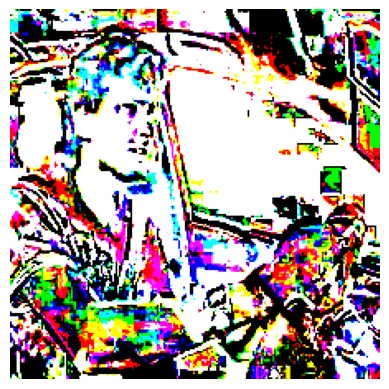

In [9]:
plt.imshow(residuals[0,1].permute((1,2,0)))
plt.axis("off")
plt.show()